# Digital Signal Processing

# FFT

From: https://pythonnumericalmethods.berkeley.edu/notebooks/chapter24.04-FFT-in-Python.html

In [2]:
import matplotlib.pyplot as plt
import numpy as np

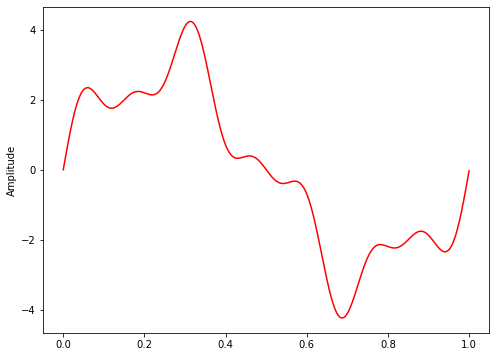

In [3]:
# sampling rate
sr = 2000
# sampling interval
ts = 1.0/sr
t = np.arange(0,1,ts)

freq = 1.
x1 = 3 * np.sin(2*np.pi*freq*t)

freq = 4
x2 = np.sin(2*np.pi*freq*t)

freq = 7
x3 = 0.5 * np.sin(2*np.pi*freq*t)

x = x1 + x2 + x3

plt.figure(figsize = (8, 6))
plt.plot(t, x, 'r')
plt.ylabel('Amplitude')

plt.show()

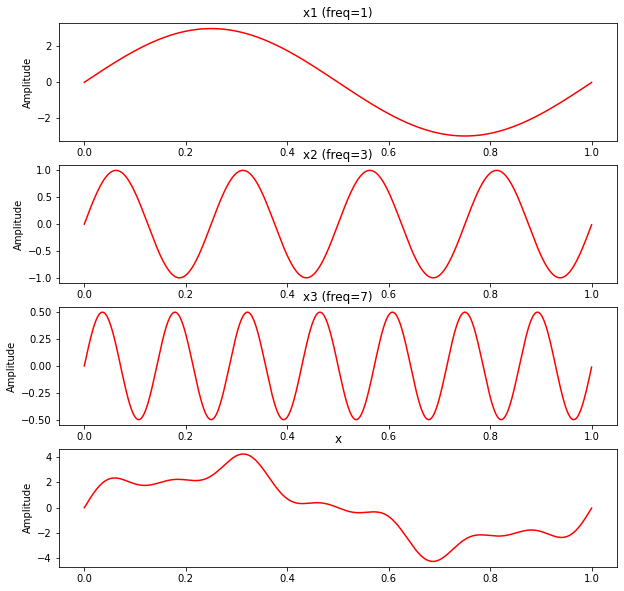

In [76]:
plt.figure(figsize=(10,10))
plt.subplot(4, 1, 1)
plt.plot(t, x1, 'r')
plt.ylabel('Amplitude')
plt.title("x1 (freq=1)")

plt.subplot(4, 1, 2)
plt.plot(t, x2, 'r')
plt.ylabel('Amplitude')
plt.title("x2 (freq=3)")

plt.subplot(4, 1, 3)
plt.plot(t, x3, 'r')
plt.ylabel('Amplitude')
plt.title("x3 (freq=7)")

plt.subplot(4, 1, 4)
plt.plot(t, x, 'r')
plt.ylabel('Amplitude')
plt.title("x")

plt.show()

/var/folders/4_/vrr8kzqn5b9dxsprxn13022m0000gn/T/ipykernel_30738/1467476092.py:12: UserWarning: In Matplotlib 3.3 individual lines on a stem plot will be added as a LineCollection instead of individual lines. This significantly improves the performance of a stem plot. To remove this warning and switch to the new behaviour, set the "use_line_collection" keyword argument to True.
  plt.stem(freq, np.abs(X) / np.sum(np.abs(X)), 'b', markerfmt=" ", basefmt="-b")
/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/matplotlib/cbook/__init__.py:1317: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


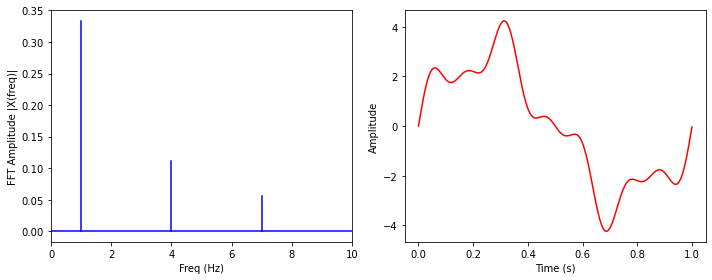

In [4]:
from numpy.fft import fft, ifft

X = fft(x)
N = len(X)
n = np.arange(N)
T = N/sr
freq = n/T

plt.figure(figsize = (10, 4))
plt.subplot(121)

plt.stem(freq, np.abs(X) / np.sum(np.abs(X)), 'b', markerfmt=" ", basefmt="-b")
plt.xlabel('Freq (Hz)')
plt.ylabel('FFT Amplitude |X(freq)|')
plt.xlim(0, 10)

plt.subplot(122)
plt.plot(t, ifft(X), 'r')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()

# Example: Sound

In [78]:
import IPython
import wave
import numpy as np
import matplotlib.pyplot as plt

In [79]:
wav_file = 'sound.wav'
# wav_file = 'sound.downsampled.wav'
IPython.display.Audio(wav_file)

### Reading file

In [80]:
with wave.open(wav_file) as wav:
    sampling_frequency = wav.getframerate() # Hz
    sample_size = wav.getsampwidth() # Byte
    num_channels = wav.getnchannels()
    num_samples = wav.getnframes()
    waveform = wav.readframes(num_samples)
    waveform = np.frombuffer(waveform, dtype=np.int16)


In [81]:
print(f"Sampling Frequency: {sampling_frequency} [Hz]")
print(f"Sample Size: {sample_size} [Byte]")
print(f"Number of Channels: {num_channels}")
print(f"Number of Samples: {num_samples}")

Sampling Frequency: 48000 [Hz]
Sample Size: 2 [Byte]
Number of Channels: 2
Number of Samples: 131072


In [82]:
# Extract the first channel
ch0 = waveform[0::2]

# Down sample from 48000 to 16000.
sampling_frequency = sampling_frequency / 3
num_samples = round(num_samples / 3)
ch0 = ch0[::3]

In [83]:
time_axis = np.arange(num_samples) / sampling_frequency

### Plotting the signal

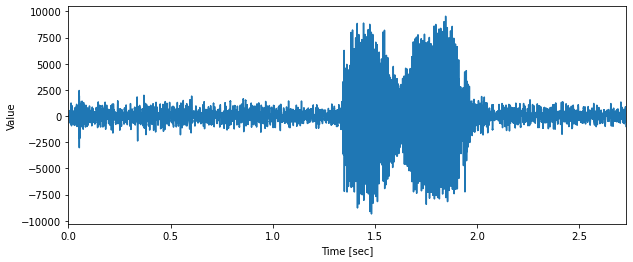

In [84]:
plt.figure(figsize=(10, 4))
plt.plot(time_axis, ch0)
plt.xlabel("Time [sec]")
plt.ylabel("Value")
plt.xlim([0, num_samples / sampling_frequency])
plt.show()

### Spectral decomposition with FFT

In [85]:
target_time = 1.25
fft_size = 1024
target_index = np.int16(target_time * sampling_frequency)
frame = ch0[target_index:target_index + fft_size]
spectrum = np.fft.fft(frame)
absolute = np.abs(spectrum)
absolute = absolute[:np.int16(fft_size/2) + 1]
log_spectrum = np.log(absolute + 1e-7)

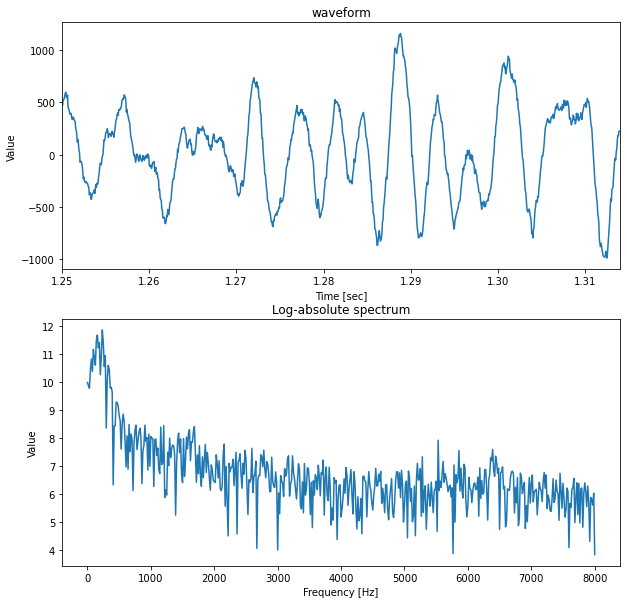

In [86]:
plt.figure(figsize=(10,10))
plt.subplot(2, 1, 1)
time_axis = target_time + np.arange(fft_size) / sampling_frequency

plt.plot(time_axis, frame)

plt.title('waveform')
plt.xlabel('Time [sec]')
plt.ylabel('Value')

plt.xlim([target_time, target_time + fft_size / sampling_frequency])

plt.subplot(2, 1, 2)
freq_axis = np.arange(np.int16(fft_size /2) + 1) * sampling_frequency / fft_size
plt.plot(freq_axis, log_spectrum)
plt.title('Log-absolute spectrum')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Value')
plt.show()

### Inverse FFT

/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/matplotlib/cbook/__init__.py:1317: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


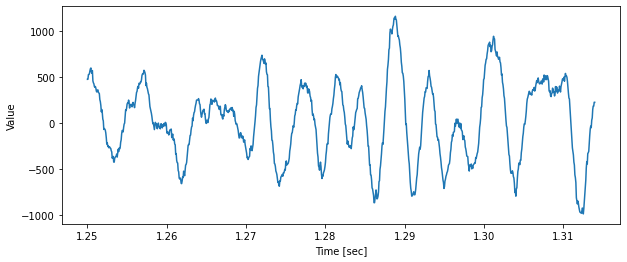

In [87]:
spectrum = np.fft.fft(frame)
inversed_signal = np.fft.ifft(spectrum)
time_axis = target_time + np.arange(fft_size) / sampling_frequency

plt.figure(figsize=(10, 4))
plt.plot(time_axis, inversed_signal)
plt.xlabel("Time [sec]")
plt.ylabel("Value")
# plt.xlim([0, num_samples / sampling_frequency])
plt.show()

# Example: Gesture

In [88]:
import numpy as np
import matplotlib.pyplot as plt
import json
from scipy.fft import fft, fftfreq

In [89]:
with open('gesture.circle.json') as fcircle, open('gesture.cross.json') as fcross:
    circle = json.load(fcircle)
    cross = json.load(fcross)

In [90]:
circle_trajectory = np.array(circle['trajectory'])
cross_trajectory = np.array(cross['trajectory'])

In [91]:
circle_x = circle_trajectory[:,0]
circle_y = circle_trajectory[:,1]
circle_t = circle_trajectory[:,2]
cross_x = cross_trajectory[:,0]
cross_y = cross_trajectory[:,1]
cross_t = cross_trajectory[:,2]

## Plotting the gestures

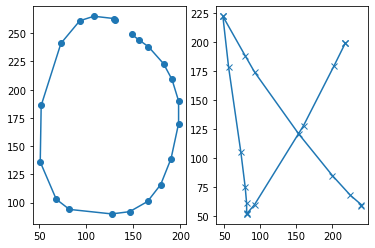

In [92]:
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.plot(circle_x, circle_y, 'o-')
ax2.plot(cross_x, cross_y, 'x-')
plt.show()

# Plotting the gestures as signals

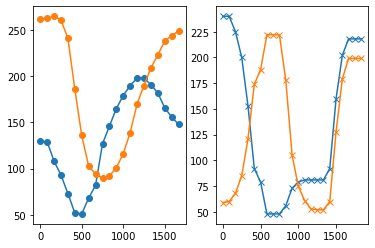

In [93]:
fig, (ax1, ax2) = plt.subplots(1, 2)

ax1.plot(circle_t, circle_x, 'o-')
ax1.plot(circle_t, circle_y, 'o-')

ax2.plot(cross_t, cross_x, 'x-')
ax2.plot(cross_t, cross_y, 'x-')
plt.show()

## Spectral decomposition

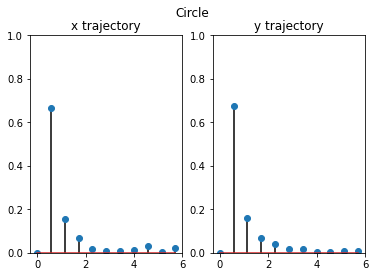

In [94]:
# Circle Gesture
N = len(circle_t)
SAMPLE_RATE = 12
end_idx = 11

f_x = fft(circle_x - np.mean(circle_x))[:end_idx]
f_x = f_x / np.sum(np.abs(f_x))

f_y = fft(circle_y - np.mean(circle_y))[:end_idx]
f_y = f_y / np.sum(np.abs(f_y))
f_dom = fftfreq(N, 1 / SAMPLE_RATE)[:end_idx]

end_idx = 11

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.suptitle("Circle")

ax1.stem(f_dom, np.abs(f_x), 'k-', use_line_collection=True)
ax1.set_ylim([0, 1])
ax1.set_title("x trajectory")

ax2.stem(f_dom, np.abs(f_y), 'k-', use_line_collection=True)
ax2.set_ylim([0, 1])
ax2.set_title("y trajectory")

plt.show()

f_circle = np.hstack((np.abs(f_x), np.abs(f_y)))


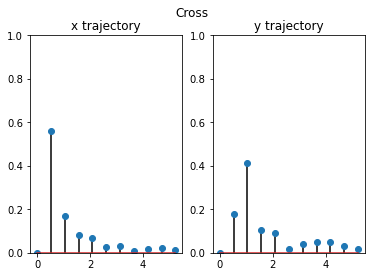

In [95]:
# Cross Gesture
N = len(cross_t)
SAMPLE_RATE = 12
end_idx = 11

f_x = fft(cross_x - np.mean(cross_x))[:end_idx]
f_x = f_x / np.sum(np.abs(f_x))
f_y = fft(cross_y - np.mean(cross_y))[:end_idx]
f_y = f_y / np.sum(np.abs(f_y))
f_dom = fftfreq(N, 1 / SAMPLE_RATE)[:end_idx]


fig, (ax1, ax2) = plt.subplots(1, 2)
fig.suptitle("Cross")
ax1.stem(f_dom, np.abs(f_x), 'k-', use_line_collection=True)
ax1.set_ylim([0, 1])
ax1.set_title("x trajectory")

ax2.stem(f_dom, np.abs(f_y), 'k-', use_line_collection=True)
ax2.set_ylim([0, 1])
ax2.set_title("y trajectory")

plt.show()

f_cross = np.hstack((np.abs(f_x), np.abs(f_y)))

## Template matching

In [96]:
with open('gesture.test.json') as ftest:
    test = json.load(ftest)
test_trajectory = np.array(test['trajectory'])

test_x = test_trajectory[:, 0]
test_y = test_trajectory[:, 1]
test_t = test_trajectory[:, 2]


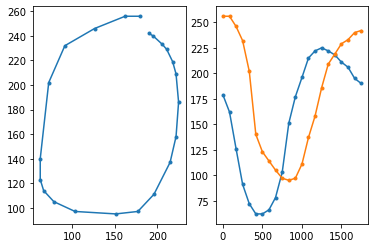

In [97]:
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.plot(test_x, test_y, '.-')

ax2.plot(test_t, test_x, '.-')
ax2.plot(test_t, test_y, '.-')
plt.show()


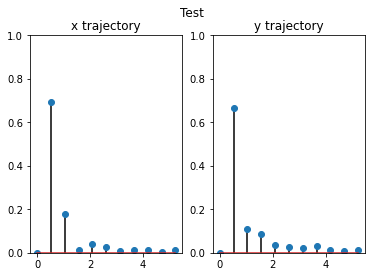

In [98]:

N = len(cross_t)
SAMPLE_RATE = 12
end_idx = 11

f_x = fft(test_x - np.mean(test_x))[:end_idx]
f_x = f_x / np.sum(np.abs(f_x))
f_y = fft(test_y - np.mean(test_y))[:end_idx]
f_y = f_y / np.sum(np.abs(f_y))
f_dom = fftfreq(N, 1 / SAMPLE_RATE)[:end_idx]

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.suptitle("Test")
ax1.stem(f_dom, np.abs(f_x), 'k-', use_line_collection=True)
ax1.set_ylim([0, 1])
ax1.set_title("x trajectory")

ax2.stem(f_dom, np.abs(f_y), 'k-', use_line_collection=True)
ax2.set_ylim([0, 1])
ax2.set_title("y trajectory")

plt.show()

f_test = np.hstack((np.abs(f_x), np.abs(f_y)))

In [99]:
np.sum(np.sqrt(np.power(f_test - f_circle, 2)))

0.31899405421373256

In [100]:
np.sum(np.sqrt(np.power(f_test - f_cross, 2)))

1.2816511635067003